# Customer Churn Analysis

## Introduction

Customer churn is one of the biggest challenges faced by subscription-based businesses. Acquiring new customers is often more expensive than retaining existing ones, making customer retention a critical factor for long-term profitability. By analyzing customer behavior, demographics, subscription details, and billing information, businesses can identify the factors that contribute to customer churn and develop strategies to improve customer retention.

This project performs an exploratory data analysis (EDA) on a telecommunications customer dataset to uncover patterns associated with customer churn and provide actionable business recommendations.

## Business Problem

A telecommunications company is experiencing customer attrition and wants to understand why customers are leaving its services. High churn rates reduce revenue, increase customer acquisition costs, and negatively impact business growth. The company needs data-driven insights to identify the characteristics of customers who are most likely to churn and implement effective retention strategies.

In [2]:
import pandas as pd
import numpy as np

### Data Inspection

In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [19]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe(include="all")

In [ ]:
df.describe(include="all")

In [ ]:
df.isnull().sum()

## Data Cleaning

Data cleaning is an essential step before analysis. In this section, the dataset is examined for data quality issues such as duplicate records, missing values, inconsistent entries, and incorrect data types. Appropriate cleaning techniques are then applied to improve the accuracy and consistency of the analysis.

### Handling Missing Values

Before replacing missing values, each affected record was inspected individually. Where the missing information could be confidently inferred from other columns or publicly available company information, the missing value was filled. Otherwise, the missing value was retained to avoid introducing unsupported assumptions into the dataset.

In [110]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Checking for Hidden Missing Values

Although `df.isnull().sum()` reported no missing values, some columns may contain blank strings (`""` or spaces) that Pandas does not recognize as `NaN`. Therefore, we do **Data Validation** by checking every column for hidden missing values before proceeding with data cleaning.

In [111]:
for col in df.columns: #col as temporary var in df.colum, iterate inside every column in the dataframe
    blanks = df[col].astype(str).str.strip().eq("").sum() #store all the white space, blanks as blank var, then sum it up
    if blanks > 0: #if any line or value inside blank var is greater than 0
        print(f"{col}: {blanks}") # show the column name & the total blanks value detected 

In [112]:
# every whitespaces,blank string under TotalCharge column should be replace by nan and string
df["TotalCharges"] = df["TotalCharges"].replace("", np.nan)

In [114]:
#convert entire value under TotalChange column and replace to numbers int,floats
df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True)

In [119]:
# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [6]:
# confirming the data types of the column if TotalCharge is now float
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# now that we have replace those blank to nan & floats, let see where the nans value are
df[df["TotalCharges"].isnull()]

In [ ]:
#as we can see the calculation for total charge is (tenure X MonthlyCharge = TotalCharges), result show that those 11 customer have 0 tenure 
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]]

In [ ]:
# For that reason, we cant determine or replace those nan values under TotalCharges so we drop them
df = df.dropna(subset=["TotalCharges"])

#### Notes on TotalCharge column
The `TotalCharges` column contained 11 missing values. Further investigation showed that all affected customers had a tenure of 0 months, indicating they were newly enrolled and had not yet accumulated any charges. Since these missing values are logically explained and represent only 11 out of 7,043 observations (approximately 0.16% of the dataset), the rows were removed to maintain data quality without significantly affecting the analysis.

In [ ]:
#After dropping the 11 row, we now have 7032 row left and 21 column intact
df.shape

In [123]:
#Checking for anymore missing Value

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [121]:
# The cleaned dataset should be exported & saved, no index.
df.to_csv("telcom_customer_churn_cleaned.csv", index=False)

# Exploratory Data Analysis (EDA)

The exploratory data analysis (EDA) aims to understand the characteristics of the telecom customers and identify patterns associated with customer churn. Through descriptive statistics and data exploration, the analysis seeks to uncover relationships between customer demographics, service subscriptions, billing information, contract types, and churn behavior. The insights generated from this analysis will help identify the key factors influencing customer retention and support data-driven business recommendations.

#### Question 1

What is the overall customer churn rate?

In [125]:
#df["Churn"].value_counts()
#proces the value count into percent rate * 100
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

#### Findings

Approximately **73.42%** of customers remained with the company, while **26.58%** of customers churned.
This indicates that although the majority of customers were retained, more than one-quarter of the customer base discontinued the service. Customer churn is therefore a significant business concern and warrants further investigation into the factors associated with customer attrition.


#### Question 2

Does customer churn differ by gender, senior citizen status, partner status, and dependents?

In [126]:
# We use crosstableto to show the difference and normalize index with percent rate to show the percentage
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


In [127]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize= "index") * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [ ]:
pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100

In [ ]:
pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100

#### Insights
Customer churn shows little variation by **gender**, with females (26.96%) and males (26.20%) exhibiting similar churn rates. However, churn differs noticeably across other demographic characteristics.

**Senior citizens** have a substantially higher churn rate (41.68%) than non-senior citizens (23.65%), suggesting that older customers are more likely to discontinue the service.

Customers **without a partner** experience a higher churn rate (32.98%) than those with a partner (19.72%). Similarly, customers **without dependents** have a higher churn rate (31.28%) compared to customers with dependents (15.53%).

Overall, senior citizen status, partner status, and dependent status appear to be associated with customer churn, whereas gender shows little relationship with customer retention.

#### Question 3 

How does customer tenure relate to churn?

In [66]:
# Using describe to summarize the whole aggregation output
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


#### Insight

Customer tenure differs considerably between customers who stayed and those who churned. Customers who remained with the company had an average tenure of **37.65 months**, compared to **17.98 months** for customers who churned.

The median tenure further supports this pattern, with retained customers having a median tenure of **38 months**, while churned customers had a median tenure of only **10 months**. Additionally, 75% of churned customers had been with the company for **29 months or less**, whereas 75% of retained customers had a tenure of **61 months or less**.

Overall, customers with shorter tenures are more likely to churn, while customers who have remained with the company for longer periods tend to have higher retention.

#### Question 4
Which contract type has the highest customer churn?

In [77]:
# Using Cross table  and convert to percentage rate
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


#### Insight
Customer churn varies considerably across contract types. Customers on **Month-to-month contracts** have the highest churn rate, with **42.71%** discontinuing the service. In contrast, customers on **One-year contracts** have a much lower churn rate of **11.28%**, while those on **Two-year contracts** exhibit the lowest churn rate at **2.85%**.

These results suggest that customers with longer-term contracts are more likely to remain with the company, whereas customers on month-to-month contracts are considerably more likely to churn.

#### Question 5

Does internet service type influence customer churn?

In [78]:
# Using Cross table  and convert to percentage rate
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


### Insight

Customer churn differs noticeably across internet service types. Customers using **Fiber optic** internet have the highest churn rate, with **41.89%** discontinuing the service. In comparison, customers with **DSL** internet have a considerably lower churn rate of **19.00%**, while customers with **No internet service** have the lowest churn rate at **7.43%**.

Overall, customer churn is highest among Fiber optic users and lowest among customers without an internet service subscription, indicating that churn varies across internet service types.

#### Question 6 

Which additional services are associated with lower customer churn?

In [80]:
# Online Security
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index") * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


In [85]:
# Online Backup
pd.crosstab(df["OnlineBackup"], df["Churn"], normalize="index") * 100

Churn,No,Yes
OnlineBackup,,
No,60.058309,39.941691
No internet service,92.565789,7.434211
Yes,78.432990,21.567010


In [84]:
# Device Protection
pd.crosstab(df["DeviceProtection"], df["Churn"], normalize="index") * 100

Churn,No,Yes
DeviceProtection,,
No,60.859729,39.140271
No internet service,92.565789,7.434211
Yes,77.460711,22.539289


In [83]:
# Tech Support
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


In [81]:
# Streaming Movies
pd.crosstab(df["StreamingMovies"], df["Churn"], normalize="index") * 100

Churn,No,Yes
StreamingMovies,,
No,66.271125,33.728875
No internet service,92.565789,7.434211
Yes,70.047602,29.952398


### Insights

Customer churn varies across additional service subscriptions. Customers with **Online Security** and **Tech Support** have substantially lower churn rates (**14.64%** and **15.20%**, respectively) compared to customers without these services (**41.78%** and **41.65%**). Similarly, customers subscribed to **Online Backup** and **Device Protection** exhibit lower churn rates (**21.57%** and **22.54%**) than those without these services (**39.94%** and **39.14%**).

In contrast, **Streaming TV** and **Streaming Movies** show only a small difference in churn rates between subscribed and non-subscribed customers, suggesting a weaker association with customer retention.

Overall, customers subscribed to Online Security, Tech Support, Online Backup, and Device Protection tend to have lower churn rates, while Streaming TV and Streaming Movies appear to have a less pronounced relationship with customer churn.

#### Question 7
Does the payment method affect customer churn?

In [88]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


#### Insight

Customer churn varies across payment methods. Customers using **Electronic check** have the highest churn rate, with **45.29%** discontinuing the service. In contrast, customers using **Credit card (automatic)** and **Bank transfer (automatic)** have much lower churn rates of **15.25%** and **16.73%**, respectively. Customers paying by **Mailed check** have a churn rate of **19.20%**, which is slightly higher than the automatic payment methods but considerably lower than Electronic check.

Overall, customer churn differs by payment method, with Electronic check users exhibiting the highest churn rate, while customers using automatic payment methods tend to have lower churn rates.

In [91]:
pd.crosstab(df["PaperlessBilling"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


#### Question 8

Is paperless billing associated with higher customer churn?

#### Insight

Customer churn differs between customers with and without paperless billing. Customers using **Paperless Billing** have a churn rate of **33.59%**, compared to **16.38%** for customers who do not use paperless billing.

Overall, customers enrolled in paperless billing exhibit a higher churn rate than those who receive traditional billing, indicating an association between paperless billing and customer churn.

#### Question 9 

How do Monthly Charges and Total Charges differ between customers who churned and those who stayed?

In [103]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


In [12]:
igo = df.groupby("Churn")["TotalCharges"].describe()

      count unique   top freq
Churn                        
No     5174   4966         11
Yes    1869   1732  20.2    6


#### Insight 

Customers who churned generally incur **higher monthly charges** but **lower total charges** than customers who remained with the company.

The average **Monthly Charges** for churned customers is **74.44**, compared to **61.31** for retained customers. The median monthly charge follows a similar pattern, with churned customers paying **79.65** compared to **64.45** for retained customers.

In contrast, customers who remained with the company have substantially higher **Total Charges**, with an average of **2,555.34** compared to **1,531.80** for customers who churned. The median total charge is also considerably higher for retained customers (**1,683.60**) than for churned customers (**703.55**).

Overall, customers who churned tend to pay higher monthly fees but have accumulated lower total charges, whereas retained customers generally have lower monthly charges and higher lifetime spending.

#### Question 10

Which customer characteristics are most commonly found among churned customers?

####

Customers who churned most commonly exhibit the following characteristics:

- Shorter customer tenure.
- Month-to-month contracts.
- Fiber optic internet service.
- Higher monthly charges.
- Lower total charges.
- Electronic check as the payment method.
- Paperless billing.
- No online security or tech support services.
- No online backup or device protection services.
- More likely to be senior citizens.
- More likely to have no partner and no dependents.

Overall, churned customers tend to be relatively newer customers with flexible contracts, higher monthly costs, fewer value-added services, and lower accumulated spending.

## Visualization

#### 1. How many customers churned vs stayed?


In [10]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

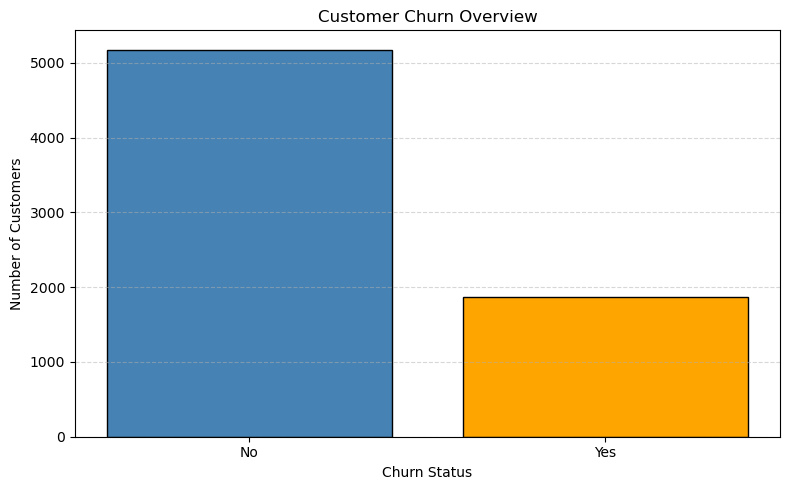

In [13]:
#Barchart

import matplotlib.pyplot as plt

# created a churn_count variable that consist of group\category churn result
churn_count = df["Churn"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(churn_count.index, churn_count.values, color=["steelblue", "orange"],edgecolor="black")

plt.title("Customer Churn Overview")

plt.xlabel("Churn Status")

plt.ylabel("Number of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#### 2. What is the distribution of customer tenure?

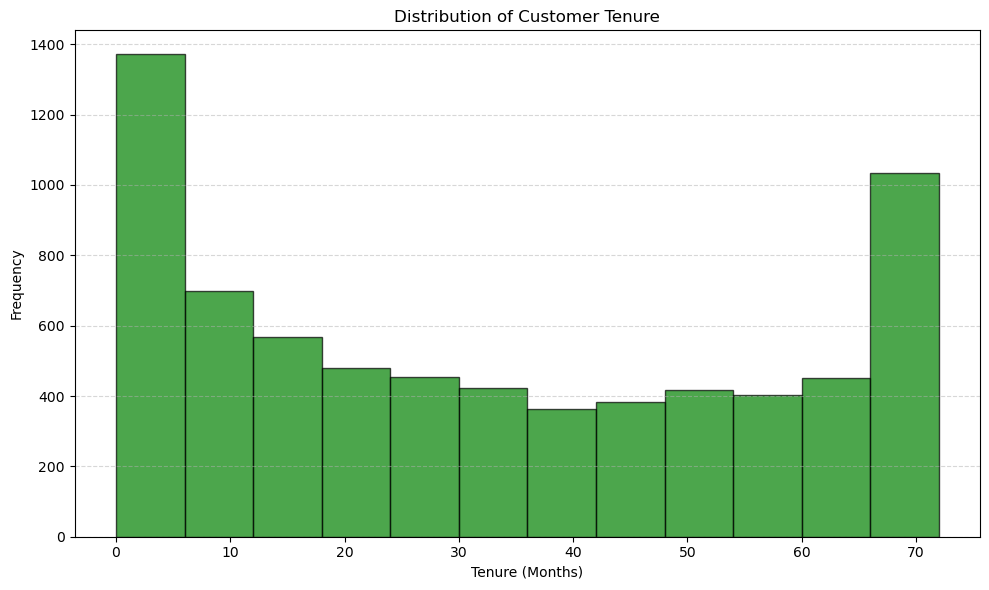

In [16]:
#Histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

#plot histogram with tenure column, seprate the result into 12 intervals, black color and transparency of 0.7
plt.hist(df["tenure"], bins=12, color="green", edgecolor="black", alpha=0.7)

plt.title("Distribution of Customer Tenure")

plt.xlabel("Tenure (Months)")

plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#### 3. Which payment method has the most customers?

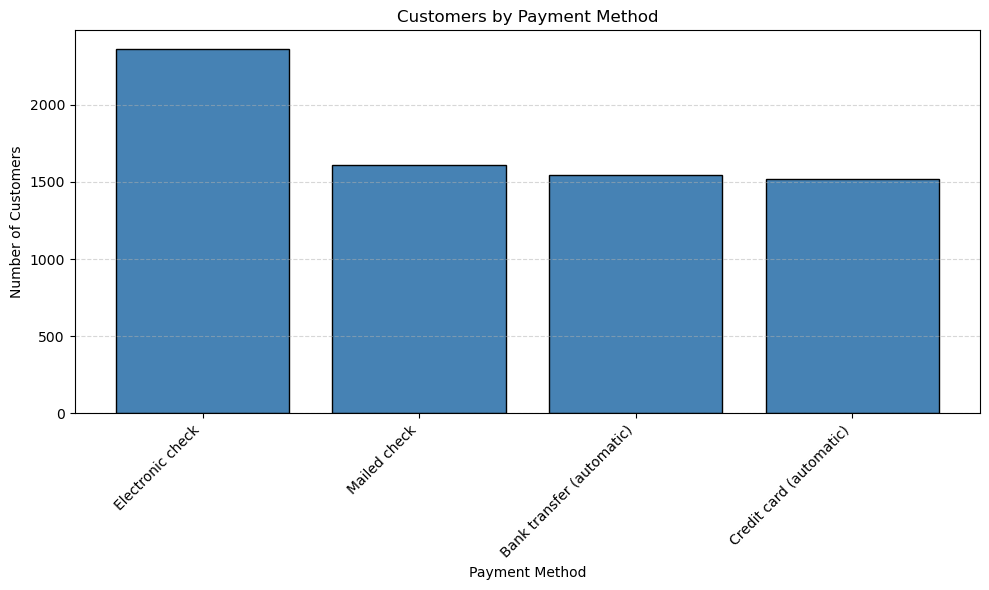

In [18]:
#Barchart
import matplotlib.pyplot as plt

payment_count = (df["PaymentMethod"] .value_counts() .sort_values(ascending=False))

plt.figure(figsize=(10, 6))

plt.bar(payment_count.index,payment_count.values, color="steelblue",edgecolor="black")

plt.title("Customers by Payment Method")

plt.xlabel("Payment Method")

plt.ylabel("Number of Customers")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()


#### 4. Which contract type has the most churn?

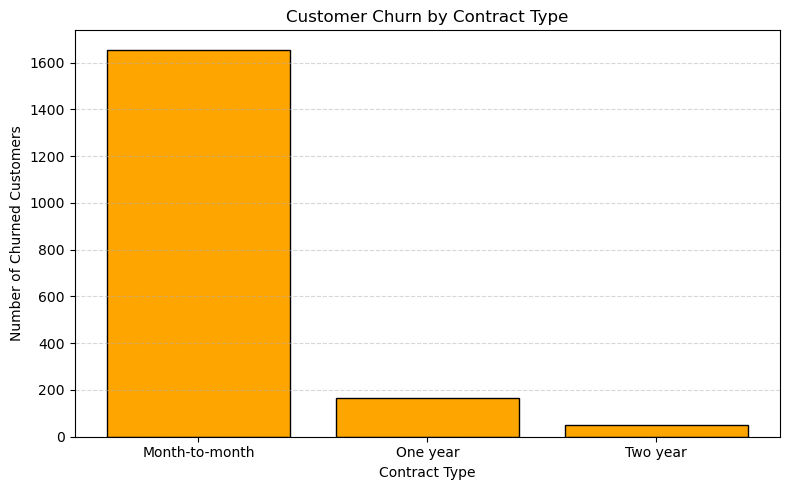

In [20]:
#Barchart

import matplotlib.pyplot as plt

#filtering out customer who churn (=yes) and wrapped it into variable called churned_customers
churned_customers = df[df["Churn"] == "Yes"]

#result of churned_customers and value count contract colum then sort from high to low
contract_churn = (churned_customers["Contract"] .value_counts().sort_values(ascending=False))

#the layout, 8 inches wide and 5 inches tall\height
plt.figure(figsize=(8, 5))

plt.bar(contract_churn.index, contract_churn.values, color="orange", edgecolor="black")

plt.title("Customer Churn by Contract Type")

plt.xlabel("Contract Type")

plt.ylabel("Number of Churned Customers")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#### 5. Is there a relationship between tenure and monthly charges?


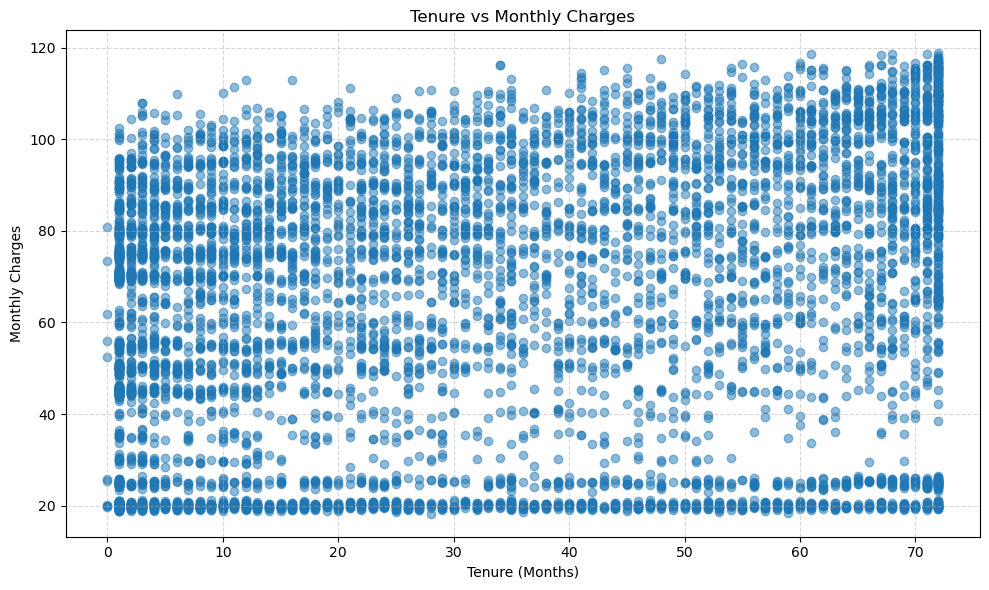

In [21]:
#Scatter plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(df["tenure"], df["MonthlyCharges"], alpha=0.5)

plt.title("Tenure vs Monthly Charges")

plt.xlabel("Tenure (Months)")

plt.ylabel("Monthly Charges")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

## Key Insights

- Approximately **26.58%** of customers discontinued the service.
- Customer churn is highest among customers on **month-to-month contracts**.
- Customers with **shorter tenure** are considerably more likely to churn.
- **Fiber optic** customers exhibit a substantially higher churn rate than DSL and non-internet customers.
- Customers using **Electronic Check** experience the highest churn rate among all payment methods.
- Customers enrolled in **Paperless Billing** have a higher churn rate than those using traditional billing.
- Customers without **Online Security**, **Tech Support**, **Online Backup**, and **Device Protection** tend to churn more frequently.
- Churned customers generally have **higher monthly charges** but **lower total accumulated charges**.
- Senior citizens, customers without partners, and customers without dependents show relatively higher churn rates.

## Business Recommendations

- Encourage customers to transition from month-to-month contracts to longer-term plans through attractive incentives.
- Implement early retention programs targeting customers during their first few months of service.
- Review pricing and service quality for Fiber optic customers to better understand the higher churn rate.
- Promote automatic payment methods by encouraging customers to switch from Electronic Check.
- Bundle value-added services such as Online Security, Tech Support, Online Backup, and Device Protection into customer plans.
- Develop targeted retention campaigns for customer groups with higher observed churn rates, including senior citizens and customers with shorter tenure.
- Continuously monitor customer churn metrics to identify high-risk customers and evaluate the effectiveness of retention strategies.

# Conclusion

This exploratory data analysis examined factors associated with customer churn in a telecommunications company using Pandas.

The analysis found that customer churn is associated with several demographic, service, billing, and contract characteristics. Customers with shorter tenure, month-to-month contracts, Fiber optic internet service, Electronic Check payments, Paperless Billing, and fewer additional service subscriptions exhibited higher churn rates. In contrast, customers with longer tenure, long-term contracts, automatic payment methods, and value-added services generally showed stronger customer retention.

These findings provide useful insights that can support customer retention initiatives and serve as a foundation for future predictive modeling to identify customers at greater risk of churning.